# 12-2. YOLO 실제 실행 입문

12-1장에서 YOLO가 무엇인지 배웠다.

이번 노트북에서는 실제 코드에서 YOLO 결과가 어떤 모양으로 나오는지 확인한다.

환경에 따라 `ultralytics`가 설치되어 있지 않을 수 있다.
그래도 노트북이 실패하지 않도록, 설치되어 있으면 실제 탐지를 실행하고 없으면 예시 결과로 구조를 연습한다.


In [1]:

from pathlib import Path
import importlib.util
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

# 결과를 저장할 폴더를 준비한다.
output_dir = Path(r"C:\work\deepLearning\deepLearning_textbook\generated_assets")
output_dir.mkdir(parents=True, exist_ok=True)


## 샘플 이미지 준비하기

YOLO를 실제로 실행하려면 이미지가 필요하다.

사용자가 가진 사진 경로를 넣어도 되지만, 이 노트북이 바로 실행될 수 있도록 간단한 샘플 이미지를 하나 만든다.

이 이미지는 실제 사진이 아니라 설명용 그림이다.
사전학습 YOLO가 꼭 물체를 탐지한다는 보장은 없다.
하지만 코드 흐름을 확인하는 데는 충분하다.


샘플 이미지 경로: C:\work\deepLearning\deepLearning_textbook\generated_assets\yolo_sample_scene.png
파일 존재 여부: True


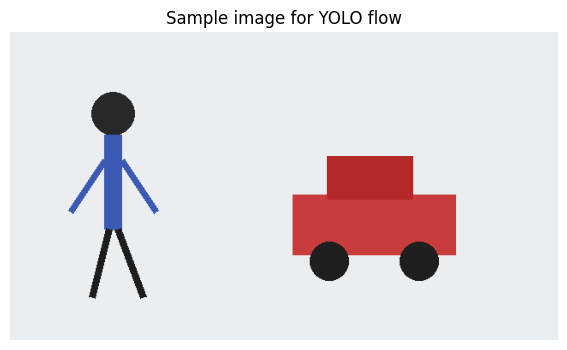

In [2]:

sample_path = output_dir / "yolo_sample_scene.png"

# 간단한 장면 이미지를 직접 만든다.
# 실제 YOLO 탐지 성능을 보려면 현실 사진을 넣는 편이 좋다.
image = Image.new("RGB", (640, 360), color=(235, 238, 240))
draw = ImageDraw.Draw(image)

# 사람처럼 보이는 단순 도형
draw.ellipse((95, 70, 145, 120), fill=(40, 40, 40))
draw.rectangle((110, 120, 130, 230), fill=(60, 90, 180))
draw.line((110, 150, 70, 210), fill=(60, 90, 180), width=8)
draw.line((130, 150, 170, 210), fill=(60, 90, 180), width=8)
draw.line((115, 230, 95, 310), fill=(30, 30, 30), width=8)
draw.line((125, 230, 155, 310), fill=(30, 30, 30), width=8)

# 자동차처럼 보이는 단순 도형
draw.rectangle((330, 190, 520, 260), fill=(200, 60, 60))
draw.rectangle((370, 145, 470, 195), fill=(180, 40, 40))
draw.ellipse((350, 245, 395, 290), fill=(30, 30, 30))
draw.ellipse((455, 245, 500, 290), fill=(30, 30, 30))

image.save(sample_path)

print("샘플 이미지 경로:", sample_path)
print("파일 존재 여부:", sample_path.exists())

plt.figure(figsize=(8, 4))
plt.imshow(image)
plt.axis("off")
plt.title("Sample image for YOLO flow")
plt.show()


## ultralytics 설치 여부 확인하기

아래 셀은 `ultralytics`가 설치되어 있는지 확인한다.

설치되어 있지 않으면 실제 YOLO 실행은 건너뛰고, 예시 결과를 사용한다.
설치하려면 VS Code 터미널에서 다음 명령을 실행할 수 있다.

```bash
pip install ultralytics opencv-python
```


In [3]:

ultralytics_available = importlib.util.find_spec("ultralytics") is not None
print("ultralytics 설치 여부:", ultralytics_available)


ultralytics 설치 여부: True


In [4]:

if ultralytics_available:
    from ultralytics import YOLO

    # yolov8n.pt는 작은 사전학습 YOLO 모델이다.
    # 첫 실행 시 모델 파일을 다운로드할 수 있다.
    yolo_model = YOLO("yolov8n.pt")
    print("YOLO 모델 준비 완료")
else:
    yolo_model = None
    print("ultralytics가 없어 실제 탐지는 건너뜁니다.")


YOLO 모델 준비 완료


## YOLO 실행하기

설치가 되어 있다면 `model.predict()`로 탐지를 실행한다.

YOLO 결과에서 먼저 볼 것은 다음 세 가지다.

```text
class name
confidence
bounding box
```


In [5]:

detections = []

if yolo_model is not None:
    results = yolo_model.predict(source=str(sample_path), save=False, verbose=False)
    result = results[0]

    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]
        confidence = float(box.conf[0])

        # xyxy는 [x1, y1, x2, y2] 형식의 박스 좌표다.
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        detections.append({
            "class": class_name,
            "confidence": confidence,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
        })

    print("실제 YOLO 탐지 수:", len(detections))
else:
    print("실제 YOLO 실행은 건너뜁니다.")


실제 YOLO 탐지 수: 0


## 탐지 결과가 없거나 실행하지 못한 경우

샘플 이미지는 실제 사진이 아니라 단순 도형이다.
그래서 YOLO가 아무것도 탐지하지 못할 수 있다.

또는 `ultralytics`가 설치되어 있지 않을 수도 있다.

그 경우에도 결과 구조를 배우기 위해 예시 탐지 결과를 사용한다.


In [6]:

if len(detections) == 0:
    detections = [
        {"class": "person", "confidence": 0.87, "x1": 70, "y1": 65, "x2": 175, "y2": 315},
        {"class": "car", "confidence": 0.81, "x1": 325, "y1": 140, "x2": 525, "y2": 292},
    ]
    print("예시 탐지 결과를 사용합니다.")

detections_df = pd.DataFrame(detections)
detections_df


예시 탐지 결과를 사용합니다.


,class,confidence,x1,y1,x2,y2
0,person,0.87,70,65,175,315
1,car,0.81,325,140,525,292


In [7]:

# confidence 기준을 적용해본다.
# 예: 0.50 이상인 탐지만 남긴다.
confidence_threshold = 0.50
filtered_df = detections_df[detections_df["confidence"] >= confidence_threshold].copy()

print("confidence 기준:", confidence_threshold)
filtered_df


confidence 기준: 0.5


,class,confidence,x1,y1,x2,y2
0,person,0.87,70,65,175,315
1,car,0.81,325,140,525,292


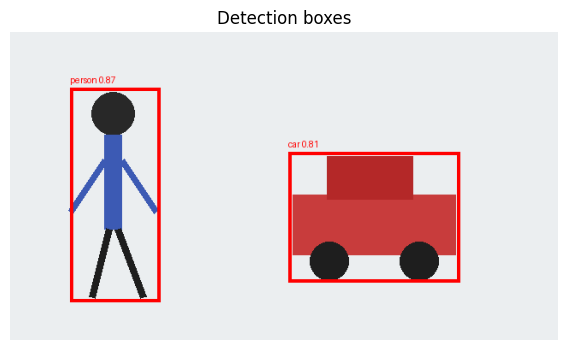

In [8]:

# 이미지 위에 bounding box를 직접 그려본다.
image_with_boxes = Image.open(sample_path).convert("RGB")
draw = ImageDraw.Draw(image_with_boxes)

for _, row in filtered_df.iterrows():
    box = [row["x1"], row["y1"], row["x2"], row["y2"]]
    label = f'{row["class"]} {row["confidence"]:.2f}'

    draw.rectangle(box, outline=(255, 0, 0), width=4)
    draw.text((row["x1"], max(0, row["y1"] - 15)), label, fill=(255, 0, 0))

plt.figure(figsize=(8, 4))
plt.imshow(image_with_boxes)
plt.axis("off")
plt.title("Detection boxes")
plt.show()


## 결과 읽기 연습

표의 각 행은 하나의 탐지 결과다.

```text
class: 물체 종류
confidence: 모델의 확신도
x1, y1: 박스의 왼쪽 위 좌표
x2, y2: 박스의 오른쪽 아래 좌표
```

객체 탐지는 이미지 하나에 답 하나를 붙이는 것이 아니라,
이미지 안의 물체마다 이런 정보를 반환한다.


In [9]:

for _, row in filtered_df.iterrows():
    sentence = (
        f"모델은 {row['class']}를 찾았고, "
        f"확신도는 {row['confidence']:.2f}, "
        f"박스 좌표는 ({row['x1']:.0f}, {row['y1']:.0f})부터 "
        f"({row['x2']:.0f}, {row['y2']:.0f})까지입니다."
    )
    print(sentence)


모델은 person를 찾았고, 확신도는 0.87, 박스 좌표는 (70, 65)부터 (175, 315)까지입니다.
모델은 car를 찾았고, 확신도는 0.81, 박스 좌표는 (325, 140)부터 (525, 292)까지입니다.


## 정리

이번 노트북에서 배운 것은 YOLO 학습이 아니라 YOLO 결과 읽기다.

반드시 기억할 구조는 다음과 같다.

```text
이미지 -> YOLO -> 여러 개의 탐지 결과

각 탐지 결과:
class + confidence + bounding box
```

포트폴리오에서 YOLO를 쓰려면 다음 단계로는 실제 사진을 넣어보고,
필요하면 직접 라벨링한 작은 데이터셋으로 확장하면 된다.
